# tap.stammer~ — the stutter, measured

The live buffer-stutter rig (`taptools/stammer.h`): the input is captured continuously, and on a
rhythmic grid the machine rolls dice and re-fires a slice of what just went past. It is an
original design in the brassage tradition (Roads, *Microsound*, MIT Press 2001) — the lineage to
Jonny Greenwood's own Max patches is about *what the object is for*, not about anything in the
code.

Two contracts carry it. The first is an identity: pin the dice to a single outcome and the whole
machine must reduce to **exactly a one-step delay**, bitwise — which is how the grid timing, the
slice origin arithmetic and the playback head get pinned together rather than one at a time. The
second is the family's seeded-randomness convention: **a seed is a performance you can replay**,
and at `density` 0 the dice are never rolled at all, so the seed provably cannot matter.

Every trace drives the **shipping C++** through `tools/capi` via ctypes.

Sections: **1** the pinned-dice identity · **2** what the dials do · **3** a seed is a performance
· **4** the disabled-generator contract · **5** the per-repeat flanks · **6** the material contract

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def stammer(**params):
    # Instant setters and a full-wet balance; sections opt into the dice.
    base = dict(smooth_ms=0, mix=100, input_level=1.0)
    base.update(params)
    return tap.Stammer(sr, 4000.0, **base)

def pluck_train(seconds, period=0.31):
    # The documented material: transients, and a phrase rather than one note repeating — real
    # playing is what this object is for, and a single repeated note would flatter it.
    pitches = np.array([196.0, 233.1, 261.6, 349.2, 293.7])
    t = np.arange(int(seconds * sr)) / sr
    phi = np.mod(t, period)
    hz = pitches[(t // period).astype(int) % pitches.size]
    out = np.zeros_like(t)
    for k in range(1, 6):
        out += (1.0 / k) * np.exp(-phi * (4.0 + 3.0 * k)) * np.sin(2 * np.pi * hz * k * phi)
    return 0.5 * out

## 1 · The pinned-dice identity

Set the dice so only one outcome is possible — always fire (`density` 1), whole-step slices
(`divisions` 1), a single pass (`repeats` 1), forwards (`reverse` 0), no reach-back (`jump` 0), no
flank (`fade` 0) — and every grid point grabs exactly the step that just went past and plays it
once. That is a pure delay of one step less one sample, and it holds sample for sample.

The value of this as a test is that three separate mechanisms fail it: an off-by-one in the grid
countdown, in the slice origin, or in the playback head. (Pinned by the kernel scenario *"with the
dice pinned, the machine is exactly a one-step delay"*.)

bitwise a one-step delay: True
max |difference|:         0.0
and not a bypass:         True


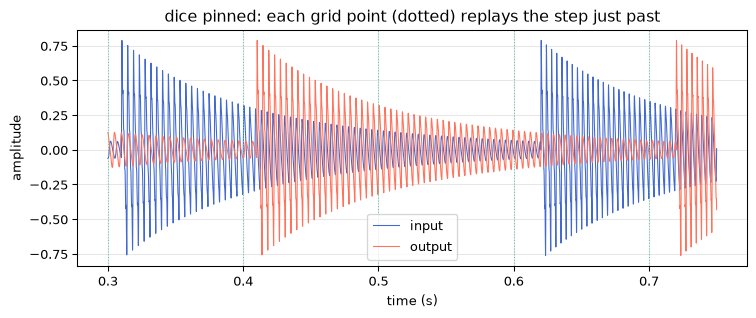

In [2]:
step_ms = 100.0
step = int(step_ms * 0.001 * sr)
x = pluck_train(1.5)

m = stammer(step_ms=step_ms, density=1.0, divisions=1, repeats=1,
            reverse=0.0, jump_ms=0.0, fade_ms=0.0)
y = m.process(x)

print(f"bitwise a one-step delay: {np.array_equal(y[step:], x[1:x.size - step + 1])}")
print(f"max |difference|:         {np.max(np.abs(y[step:] - x[1:x.size - step + 1]))}")
print(f"and not a bypass:         {not np.array_equal(y[step:], x[step:])}")

fig, ax = plt.subplots()
w = slice(int(0.30 * sr), int(0.75 * sr))
t = np.arange(x.size)[w] / sr
ax.plot(t, x[w], color=C[0], lw=0.8, label="input")
ax.plot(t, y[w], color=C[2], lw=0.8, label="output")
for g in range(3, 8):
    ax.axvline(g * step / sr, color=C[3], lw=0.8, ls=":")
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title("dice pinned: each grid point (dotted) replays the step just past")
ax.legend()
plt.show()

## 2 · What the dials do

`density` is how often the machine grabs at an idle grid point; `repeats` is how many passes it
holds on for once it has. They are not interchangeable — a slice in flight is never interrupted,
so `repeats` is what actually decides how long the machine stays busy, and past the point where
trains overlap, raising density stops having an effect.

Below, the busy fraction measured directly off the object's `playing` flag, sample by sample.

  density 0.3, repeats 1: busy  41.0% of the time (100 grid points)
  density 0.3, repeats 6: busy  76.0% of the time (100 grid points)
  density 0.9, repeats 1: busy  90.0% of the time (100 grid points)


  density 0.9, repeats 6: busy  96.0% of the time (100 grid points)


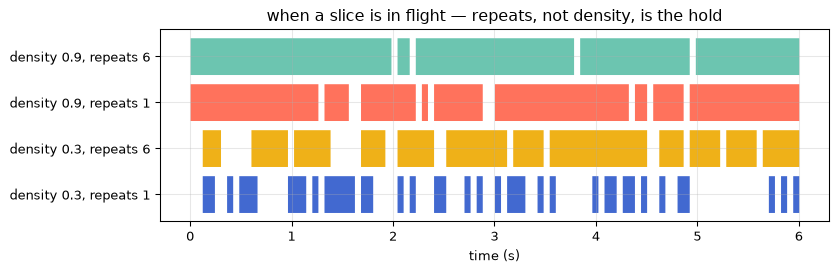

In [3]:
def occupancy(seconds=6.0, **params):
    m = stammer(**params)
    src = pluck_train(seconds)
    flags = np.zeros(src.size, dtype=bool)
    for i, v in enumerate(src):
        m.process(np.array([v]))
        flags[i] = m.playing
    return flags

step_ms = 60.0  # 100 grid points across the 6 s render: enough for the fractions to mean something
runs = {
    "density 0.3, repeats 1": dict(step_ms=step_ms, density=0.3, divisions=1, repeats=1, seed=7),
    "density 0.3, repeats 6": dict(step_ms=step_ms, density=0.3, divisions=1, repeats=6, seed=7),
    "density 0.9, repeats 1": dict(step_ms=step_ms, density=0.9, divisions=1, repeats=1, seed=7),
    "density 0.9, repeats 6": dict(step_ms=step_ms, density=0.9, divisions=1, repeats=6, seed=7),
}
flags = {k: occupancy(**v) for k, v in runs.items()}

fig, ax = plt.subplots(figsize=(9, 2.6))
for n, (label, f) in enumerate(flags.items()):
    ax.fill_between(np.arange(f.size) / sr, n, n + f * 0.8, color=C[n], step="mid", lw=0)
    print(f"{label:>24}: busy {100.0 * f.mean():5.1f}% of the time "
          f"({int(6.0 * 1000.0 / step_ms)} grid points)")
ax.set_yticks([n + 0.4 for n in range(len(flags))]); ax.set_yticklabels(list(flags))
ax.set_xlabel("time (s)")
ax.set_title("when a slice is in flight — repeats, not density, is the hold")
plt.show()

## 3 · A seed is a performance you can replay

Every draw — fire, division, repeat count, reach-back, and the per-repeat coin for reverse —
comes from the family's seeded xorshift64* in a fixed order. Two runs of the same seed and the
same moves are bit-identical; two seeds are genuinely different performances, not a cosmetic
reshuffle. That is what makes a render reproducible and what lets two instances decorrelate.

same seed, bitwise identical: True
different seed, differs in:   89.4% of samples


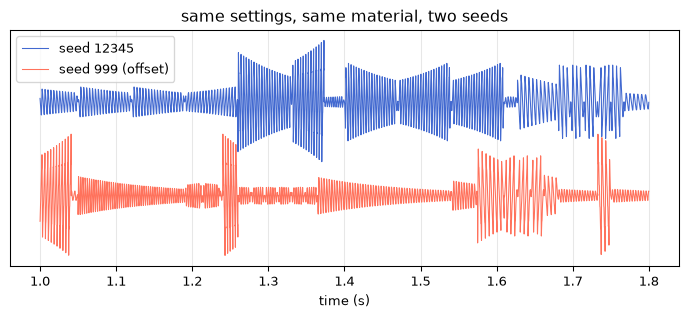

In [4]:
def run(seed):
    m = stammer(step_ms=70.0, density=0.6, divisions=4, repeats=6,
                reverse=0.4, jump_ms=120.0, fade_ms=3.0, seed=seed)
    return m.process(pluck_train(3.0))

a, b, cc = run(12345), run(12345), run(999)
print(f"same seed, bitwise identical: {np.array_equal(a, b)}")
print(f"different seed, differs in:   {100.0 * np.mean(a != cc):.1f}% of samples")

fig, ax = plt.subplots()
w = slice(int(1.0 * sr), int(1.8 * sr))
t = np.arange(a.size)[w] / sr
ax.plot(t, a[w], color=C[0], lw=0.8, label="seed 12345")
ax.plot(t, cc[w] - 1.2, color=C[2], lw=0.8, label="seed 999 (offset)")
ax.set_xlabel("time (s)"); ax.set_yticks([])
ax.set_title("same settings, same material, two seeds")
ax.legend()
plt.show()

## 4 · The disabled-generator contract

`garden.h` established the shape: a generator that is switched off must not consume its random
stream, so the seed provably cannot matter. Here `density` 0 means the dice are never rolled —
and because nothing ever fires, the object is also a bitwise bypass at any mix (there is nothing
to blend against, and equal-power blending a signal with itself would only make it louder).

In [5]:
src = pluck_train(1.0)
quiet_a = stammer(step_ms=70.0, density=0.0, seed=1).process(src)
quiet_b = stammer(step_ms=70.0, density=0.0, seed=0xfeedface).process(src)
mid_mix = tap.Stammer(sr, 4000.0, smooth_ms=0, mix=50, step_ms=70.0, density=0.0).process(src)

print(f"two seeds give identical output: {np.array_equal(quiet_a, quiet_b)}")
print(f"and it is a bitwise bypass:      {np.array_equal(quiet_a, src)}")
print(f"still bitwise at mix 50:         {np.array_equal(mid_mix, src)}")

two seeds give identical output: True
and it is a bitwise bypass:      True
still bitwise at mix 50:         True


## 5 · The per-repeat flanks

Each repeat gets a raised-sine flank at both edges: exactly zero at the edges, exactly unity
across the plateau. Repeats are sequential rather than overlapped, so every junction dips to
zero — that is the articulation of a stutter, and it is deliberate rather than a crossfade that
failed.

Driving the machine with a held DC input makes the slice material exactly 1.0, so the output *is*
the envelope.

opens at exactly zero:  True
closes at exactly zero: True
plateau is exactly one: True


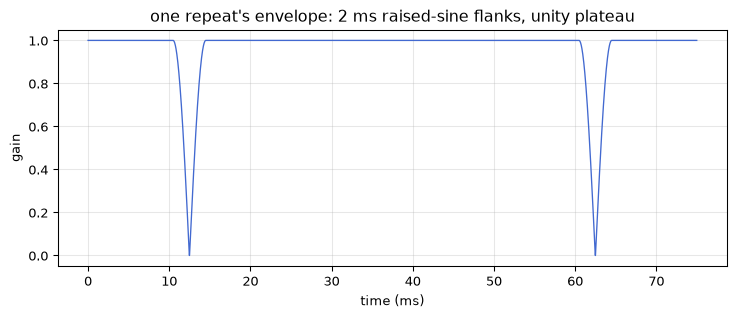

In [6]:
step_ms, fade_ms = 50.0, 2.0
step, fade = int(step_ms * 0.001 * sr), int(fade_ms * 0.001 * sr)
m = stammer(step_ms=step_ms, density=1.0, divisions=1, repeats=1,
            reverse=0.0, jump_ms=0.0, fade_ms=fade_ms)
env = m.process(np.ones(int(0.5 * sr)))

base = 2 * step
print(f"opens at exactly zero:  {env[base] == 0.0}")
print(f"closes at exactly zero: {env[base + step - 1] == 0.0}")
print(f"plateau is exactly one: {env[base + fade] == 1.0 and env[base + step // 2] == 1.0}")

fig, ax = plt.subplots()
seg = env[base - step // 4 : base + step + step // 4]
ax.plot(np.arange(seg.size) / sr * 1000.0, seg, color=C[0], lw=1.0)
ax.set_xlabel("time (ms)"); ax.set_ylabel("gain")
ax.set_title(f"one repeat's envelope: {fade_ms:.0f} ms raised-sine flanks, unity plateau")
plt.show()

## 6 · The material contract, measured

The header states it plainly: this object wants transient material, and on a sustained tone a
stutter is barely distinguishable from a tremolo. That is not a taste claim — it is a property of
self-similarity. Every slice of a steady sine looks like every other slice, so re-ordering them
changes almost nothing; slices of a plucked phrase are all different, so re-ordering them is the
whole effect.

What is measurable here is the premise, and it is a property of the *material*, not of the
machine: how alike are two arbitrary slices of it? Below, many random slices of each material are
compared by magnitude spectrum (phase-free, since a stutter re-orders slices without regard to
phase) and averaged pairwise. A number near 1 means every slice looks like every other one — and
re-ordering interchangeable things cannot do much.

 sustained sine (196 Hz): slices are 1.000 alike
          plucked phrase: slices are 0.286 alike


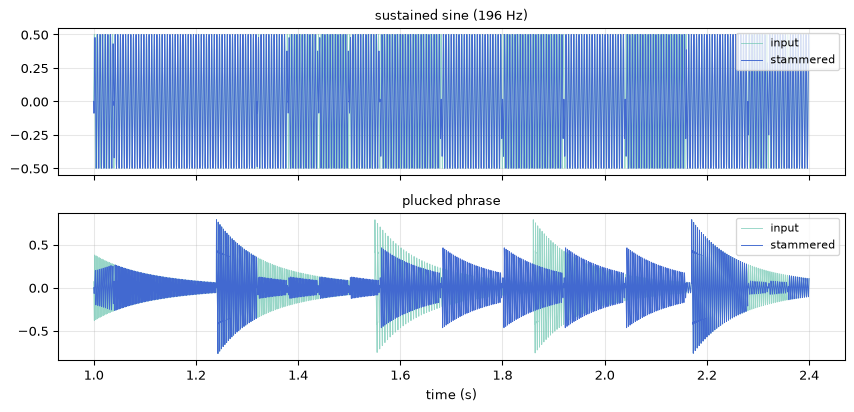

In [7]:
def slice_similarity(x, win_ms=60.0, n=96, seed=0):
    # Mean pairwise cosine similarity of the magnitude spectra of n random slices.
    rng = np.random.default_rng(seed)
    w = int(win_ms * 0.001 * sr)
    window = np.hanning(w)
    specs = []
    for start in rng.integers(0, x.size - w, n):
        s = np.abs(np.fft.rfft(x[start:start + w] * window))
        norm = np.linalg.norm(s)
        if norm > 0:
            specs.append(s / norm)
    specs = np.array(specs)
    gram = specs @ specs.T
    iu = np.triu_indices(specs.shape[0], 1)
    return float(gram[iu].mean())

t = np.arange(int(3.0 * sr)) / sr
materials = {
    "sustained sine (196 Hz)":  0.5 * np.sin(2 * np.pi * 196.0 * t),
    "plucked phrase":           pluck_train(3.0),
}
for label, src in materials.items():
    print(f"{label:>24}: slices are {slice_similarity(src):.3f} alike")

# What the machine does with each is the consequence, not a second measurement: the same seeded
# performance, plotted on both materials.
settings = dict(step_ms=120.0, density=0.8, divisions=4, repeats=5,
                reverse=0.4, jump_ms=250.0, fade_ms=3.0, seed=5)
fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True)
for ax, (label, src) in zip(axes, materials.items()):
    out = stammer(**settings).process(src)
    w = slice(int(1.0 * sr), int(2.4 * sr))
    ax.plot(np.arange(src.size)[w] / sr, src[w], color=C[3], lw=0.7, alpha=0.7, label="input")
    ax.plot(np.arange(out.size)[w] / sr, out[w], color=C[0], lw=0.7, label="stammered")
    ax.set_title(label, fontsize=10); ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## Checkpoint

- With the dice pinned to one outcome the machine is **bitwise** a one-step delay — grid, origin
  and playback head all pinned by one identity.
- `repeats`, not `density`, is what holds the machine busy; a slice in flight is never
  interrupted.
- A seed is a performance: same seed, bit-identical render; different seed, a different
  performance.
- At `density` 0 the dice are never rolled, and the object is a bitwise bypass at any mix.
- Each repeat's flanks reach exactly zero and its plateau is exactly unity.
- The material contract rests on a measurable property of the material itself: slices of a
  sustained sine are nearly interchangeable, slices of a plucked phrase are not — and re-ordering
  interchangeable things is close to a no-op. Feed this object transients.